In [1]:
import pandas as pd 
import os
import h5py 
from scipy.stats import spearmanr, kendalltau, pearsonr
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_absolute_error

from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge

import matplotlib.pyplot as plt
import seaborn as sns  # pip install seaborn

### Load H5 file (example)

In [ ]:
base_p = '/Prove/Albisani/medrank_iqa_network_features_analysis'

current_model = 'features_vgg16_full_syn_real_balanced_v1_or_per_0.5_test.h5'

features_path = os.path.join(base_p, current_model)

with h5py.File(features_path, "r") as f:
    print(f.keys())
    X = f["relu5_3"][:]   # choose the layer , these are the features extracted from the corresponding layer
    y = f["scores"][:]  # gt scores
    y_pred = f["preds"][:]  # predictions of the model 
    paths = f["paths"][:]  # paths of the images

paths = [p.decode("utf-8") if isinstance(p, bytes) else p for p in paths]

print("Shapes:", X.shape, y.shape, y_pred.shape)

idx = 25
print(f"{idx} sample:")
print(paths[idx], y[idx], y_pred[idx])

<KeysViewHDF5 ['paths', 'preds', 'relu2_2', 'relu3_3', 'relu5_3', 'relu6_m', 'relu7_m', 'scores']>
Shapes: (300, 512) (300,) (300,)
25 sample:
/Prove/Albisani/LDCTIQA_dataset/LDCTIQAC2023_test/test_0/L291_412_1_4.tif 1.8333334 0.0


### Probing

In [2]:
def load_h5_features(path):
    with h5py.File(path, "r") as f:
        data = {
            "scores": f["scores"][:],
            "preds": f['preds'][:],
            "paths": f['paths'][:]
        }

        # prendi tutti i layer (escludi metadata)
        layers = [k for k in f.keys() if k not in ["scores", "paths", "preds"]]

        for l in layers:
            data[l] = f[l][:]

    return data, layers

def linear_probe(X_train, y_train, X_test, y_test, alpha=1.0):
    # standardizzazione
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # modello lineare  TODO: prova altri modelli lineari ...
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # metriche
    srcc = spearmanr(y_test, y_pred)[0]
    plcc = pearsonr(y_test, y_pred)[0]
    mae  = np.mean(np.abs(y_test - y_pred))

    return {
        "y_pred": y_pred,
        "SRCC": srcc,
        "PLCC": plcc,
        "MAE": mae
    }

def nonlinear_probe(X_train, y_train, X_test, y_test, model_type="svr"):

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    if model_type == "svr":
        model = SVR(kernel='rbf', C=10, gamma='scale')

    elif model_type == "mlp":
        model = MLPRegressor(hidden_layer_sizes=(256,128), max_iter=500)

    elif model_type == "krr":
        model = KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1)

    else:
        raise ValueError("unknown model")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "y_pred": y_pred,
        "SRCC": spearmanr(y_test, y_pred)[0],
        "PLCC": pearsonr(y_test, y_pred)[0],
        "MAE": mean_absolute_error(y_test, y_pred)
    }

In [3]:
base_p = '/Prove/Albisani/medrank_iqa_network_features_analysis'

current_model = 'features_vgg16_full_syn_real_balanced_v1_or_per_0.5'
# current_model = 'features_vgg16_Rank_tid2013.caffemodel.pt'

lp = 1  # 1: linear probe , 0: non linear probe
# TODO: metti anche un layer lineare da addestrare per provare ...
 
model_type = 'svr'  # per non_linear_probe
####################################################################

features_train_path = os.path.join(base_p, current_model + '_train.h5')
features_test_path = os.path.join(base_p, current_model + '_test.h5')

train_data, layers = load_h5_features(features_train_path)
test_data, _       = load_h5_features(features_test_path)

y_train = train_data["scores"]
y_test  = test_data["scores"]

print("\n=== Linear Probing Results ===\n")

results = {}
path_pred_dict = {}

paths = test_data["paths"]
paths = [p.decode() if isinstance(p, bytes) else p for p in paths]

for layer in layers:
    print(f"Processing layer: {layer}")

    X_train = train_data[layer]  # features
    X_test  = test_data[layer]

    if lp == 1: 
        metrics = linear_probe(X_train, y_train, X_test, y_test)
    else:
        metrics = nonlinear_probe(X_train, y_train, X_test, y_test, model_type=model_type)

    results[layer] = metrics

    print(f"  SRCC: {metrics['SRCC']:.4f}")
    print(f"  PLCC: {metrics['PLCC']:.4f}")
    print(f"  MAE : {metrics['MAE']:.4f}\n")

    y_pred_model = metrics['y_pred']

    path_pred_dict[layer] = {
        paths[i]: float(y_pred_model[i]) for i in range(len(paths))
    }
    # dizionario path, pred 

# summary finale
print("\n=== Summary ===")
for layer, m in results.items():
    print(f"{layer:10s} | SRCC: {m['SRCC']:.4f} | PLCC: {m['PLCC']:.4f}")



=== Linear Probing Results ===

Processing layer: relu2_2
  SRCC: 0.8649
  PLCC: 0.8579
  MAE : 0.4657

Processing layer: relu3_3
  SRCC: 0.8461
  PLCC: 0.8336
  MAE : 0.4772

Processing layer: relu5_3
  SRCC: 0.7648
  PLCC: 0.6525
  MAE : 0.6325

Processing layer: relu6_m
  SRCC: 0.5828
  PLCC: 0.4969
  MAE : 0.9433

Processing layer: relu7_m
  SRCC: 0.5881
  PLCC: 0.4934
  MAE : 0.9148


=== Summary ===
relu2_2    | SRCC: 0.8649 | PLCC: 0.8579
relu3_3    | SRCC: 0.8461 | PLCC: 0.8336
relu5_3    | SRCC: 0.7648 | PLCC: 0.6525
relu6_m    | SRCC: 0.5828 | PLCC: 0.4969
relu7_m    | SRCC: 0.5881 | PLCC: 0.4934


### Basic plots

In [4]:
def compute_corrs(x):
    return pd.Series({
        'pearson': x['score'].corr(x['pred'], method='pearson'),
        'spearman': x['score'].corr(x['pred'], method='spearman'),
        'kendall': x['score'].corr(x['pred'], method='kendall')
    })

def noise_streak_heatmap(pred, mos, noise, streak):

    pred = np.asarray(pred).ravel()
    mos = np.asarray(mos).ravel()
    noise = np.asarray(noise).ravel()
    streak = np.asarray(streak).ravel()

    results = np.zeros((4,3))

    for n in range(4):
        for s in range(3):

            idx = (noise == n) & (streak == s)

            if np.sum(idx) < 3:   # troppo pochi campioni
                results[n, s] = np.nan
            else:
                results[n, s] = spearmanr(pred[idx], mos[idx])[0]  # TODO:pvalue da guardare
            
                # counts[n,s] = np.sum(idx) TODO: conta quanti campioni 

    return results

/tmp/ipykernel_27879/2075196962.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corrs = df_test.groupby('code').apply(compute_corrs)  # you can try for 'noise_level', 'streak_level'


<Axes: xlabel='code'>

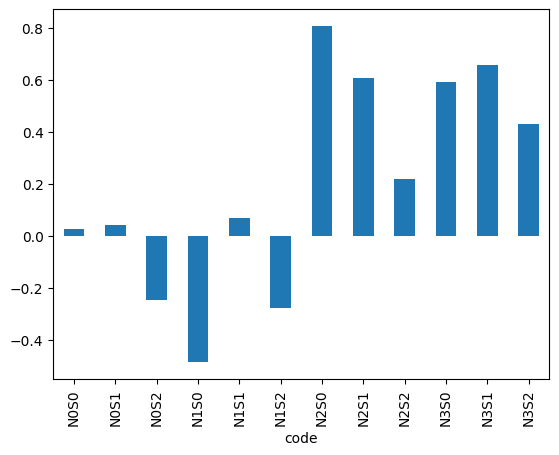

In [5]:
csv_test = '/Prove/Albisani/LDCTIQA_dataset/LDCTIQAC2023_test/test_map.csv'
df_test = pd.read_csv(csv_test, index_col=0)

layer_chosen = 'relu2_2'

predictions_clean = {k.split('/')[-1].replace('.tif', ''): v for k, v in path_pred_dict[layer_chosen].items()}  

df_test['pred'] = df_test['image_name'].map(predictions_clean)

corrs = df_test.groupby('code').apply(compute_corrs)  # you can try for 'noise_level', 'streak_level'

corrs['spearman'].plot(kind='bar')  # .sort_values()
# you can try pearsonr or kenadall

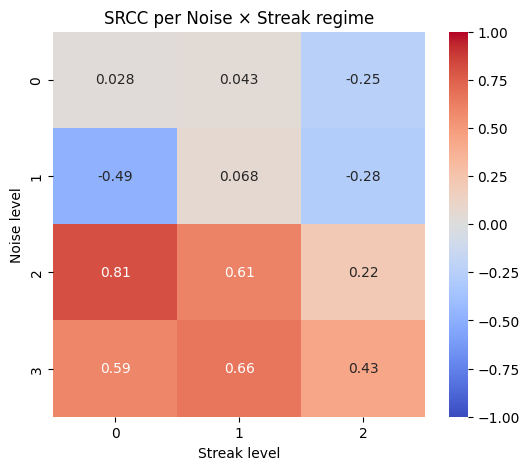

In [ ]:
predictions_clean = {k.split('/')[-1].replace('.tif', ''): v for k, v in path_pred_dict[layer_chosen].items()}

df = df_test.copy()
df["pred"] = df["image_name"].map(predictions_clean)
df = df.dropna(subset=["pred", "noise_level", "streak_level"])

pred = np.array(df['pred'].values)
mos = np.array(df['score'].values)

noise = np.array(df["noise_level"].values)  # .reshape(-1,1)
streak = np.array(df["streak_level"].values) # .reshape(-1,1)


mat = noise_streak_heatmap(pred, mos, noise, streak)

plt.figure(figsize=(6,5))
sns.heatmap(
    mat,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=[0,1,2],
    yticklabels=[0,1,2,3]
)

plt.xlabel("Streak level")
plt.ylabel("Noise level")
plt.title("SRCC per Noise × Streak")
plt.show()

In [7]:
from scipy.stats import spearmanr, pearsonr

print("SRCC noise-MOS:", spearmanr(noise, mos)[0])
print("SRCC streak-MOS:", spearmanr(streak, mos)[0])

SRCC noise-MOS: -0.5230141698769057
SRCC streak-MOS: -0.7741404569621498
